## Simple Neural ODE 

In [171]:
import time

import jax
import jax.numpy as jnp
import jax.nn as jnn
import jax.random as jr
from diffrax import backward_hermite_coefficients, CubicInterpolation
from jaxtyping import Array, PRNGKeyArray
from typing import Callable

import diffrax
import equinox as eqx

import optax


from functools import partial

import numpy as np
import matplotlib.pyplot as plt

In [172]:
# Load the data
data = jnp.load('juggle_data.npz')
ts = data['ts']       # shape: (T,)
us = data['us']       # shape: (N, T, DOF)
qs = data['qs']       # shape: (N, T, DOF)
qs_t = data['qs_t']   # shape: (N, T, DOF)
qs_tt = data['qs_tt'] # shape: (N, T, DOF)

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

T_total = ts.shape[0]
T_cut = int(0.5 * T_total)

# 2. Truncate the time series
ts = ts[:T_cut]
us = us[:, :T_cut, :]
qs = qs[:, :T_cut, :]
qs_t = qs_t[:, :T_cut, :]
qs_tt = qs_tt[:, :T_cut, :]

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)



ts shape: (5001,)
us shape: (50, 5001, 4)
qs shape: (50, 5001, 4)
ts shape: (2500,)
us shape: (50, 2500, 4)
qs shape: (50, 2500, 4)


In [173]:
# Compute Standardization statistics on the *entire* dataset BEFORE splitting
qs_mean, qs_std = jnp.mean(qs, axis=(0,1)), jnp.std(qs, axis=(0,1))
qs_t_mean, qs_t_std = jnp.mean(qs_t, axis=(0,1)), jnp.std(qs_t, axis=(0,1))
qs_tt_mean, qs_tt_std = jnp.mean(qs_tt, axis=(0,1)), jnp.std(qs_tt, axis=(0,1))
us_mean, us_std = jnp.mean(us, axis=(0,1)), jnp.std(us, axis=(0,1))

print ("Standardization data:")
print ("degree_mean:",qs_mean, "degree_std:",qs_std)
print ("velocity_mean:",qs_t_mean, "velocity_std:",qs_t_std)
print ("acceleration_mean:",qs_tt_mean, "acceleration_std:",qs_tt_std)
print ("torque_mean:",us_mean, "torque_std:",us_std)




Standardization data:
degree_mean: [7.7221874e-04 1.0332161e+00 1.1567774e-03 1.1066628e+00] degree_std: [0.154935   0.15713288 0.10738045 0.1683601 ]
velocity_mean: [ 0.00665494  0.00546817  0.00053695 -0.01186672] velocity_std: [1.0029976 1.5492026 0.613365  1.8483601]
acceleration_mean: [-0.17164373  0.23890488  0.03558724  0.157787  ] acceleration_std: [ 7.856468  20.680706   5.8901777 32.150173 ]
torque_mean: [-0.17494874 -4.3679194   0.04430274 -1.5036372 ] torque_std: [ 7.8457475 26.273884   2.3094869  9.124658 ]


In [174]:
# Number of training trajectories
n_train = 40

# Split the data along the trajectory axis (axis=0)
qs_train = qs[:n_train]
qs_t_train = qs_t[:n_train]
qs_tt_train = qs_tt[:n_train]
us_train = us[:n_train]

qs_test = qs[n_train:]
qs_t_test = qs_t[n_train:]
qs_tt_test = qs_tt[n_train:]
us_test = us[n_train:]




qs_train_std = (qs_train - qs_mean) / qs_std
qs_train_t_std = (qs_t_train - qs_t_mean) / qs_t_std
qs_train_tt_std = (qs_tt_train - qs_tt_mean) / qs_tt_std
us_train_std = (us_train - us_mean) / us_std




# Simple Neural ODE  + manual ode solver (Euler or Runge Kutta)
### inputs [q , q_t , u]
### output [q_tt]

In [175]:
class NeuralODE(eqx.Module):
    mlp: eqx.nn.MLP
    solver: diffrax.AbstractSolver
    stepsize_controller: diffrax.AbstractStepSizeController
    state_size: int

    def __init__(
        self, 
        state_size: int = 12,      # 4 Position , 4 velocity 4, 4 torque
        output_size: int = 4,      # 4 accelerations 
        nn_width: int = 128,
        nn_depth: int = 2,
        *,
        key: PRNGKeyArray,
        solver: diffrax.AbstractSolver = diffrax.Tsit5(),
        stepsize_controller: diffrax.AbstractStepSizeController = diffrax.PIDController(rtol=1e-3, atol=1e-6),
    ):
        super().__init__()
        self.state_size = state_size
        self.solver = solver
        self.stepsize_controller = stepsize_controller

        self.mlp = eqx.nn.MLP(
            in_size=state_size,
            out_size=output_size,
            width_size=nn_width,
            depth=nn_depth,
            activation=jnn.softplus,
            key=key
        )

    def __call__(self, y: Array) -> Array:
        """Predict dy/dt given state y"""
        return self.mlp(y)

In [176]:
def _dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = min(batch_size, dataset_size)
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size
@eqx.filter_value_and_grad                    
def grad_loss(model, y, y_t):                 
    y_t_pred = jax.vmap(model)(y)
    return jnp.mean((y_t - y_t_pred) ** 2)

@eqx.filter_jit                                 
def make_step(y, y_t, model, optim, opt_state): 
    loss, grads = grad_loss(model, y, y_t)   
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)   
    return loss, model, opt_state

# lr = learning rate 
def train(
    model, training_data,
    *, key,
    batch_size=64,
    lr=1e-3,
    steps=1000,
    print_every=100,
    ):

    y, y_t = training_data

    losses = []

    start_time = time.time()
    optim = optax.adabelief(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
    for step, (_y, _y_t) in zip(
        range(steps), _dataloader((y, y_t), batch_size, key=key)
    ):
        loss, model, opt_state = make_step(_y, _y_t, model, optim, opt_state)
        losses.append(loss)
        if (step % print_every) == 0 or step == steps - 1:
            print(f"Step: {step}, Loss: {loss:.3e}")
    training_time = time.time() - start_time
    print(f'Training took: {training_time:-2f}s')

    return model, losses

In [178]:
y0_test = jnp.concatenate([qs_test[:, 0, :], qs_t_test[:, 0, :]], axis=-1)  # build the intial condition based on T0 data from test data for post processing
us_test = us_test  # Already in correct shape from your dataset
print (y0_test[0])
print (y0_test.shape)
print (us_test.shape)
y_test = jnp.concatenate([qs_test, qs_t_test], axis=-1) 


N, T, DOF = qs.shape

#Reshape to (N*T, DOF) for derivative fitting
qs_flat = qs_train_std.reshape(-1, DOF)       # (N*T, 4)
qs_t_flat = qs_train_t_std.reshape(-1, DOF)   # (N*T, 4)
qs_tt_flat = qs_train_tt_std.reshape(-1, DOF) # (N*T, 4)
us_flat = us_train_std.reshape(-1, DOF)       # (N*T, 4)



x = jnp.concatenate([qs_flat, qs_t_flat, us_flat], axis=-1) # input [q , q_t , u]

y = jnp.concatenate( [qs_tt_flat], axis=-1) # output  [q_tt]

derivative_data_train = (x, y) 

print(derivative_data_train[0].shape)
print(derivative_data_train[1].shape)

[-0.1   1.12  0.    1.28  0.    0.    0.    0.  ]
(10, 8)
(10, 2500, 4)
(100000, 12)
(100000, 4)


In [179]:
import time
key = jr.key(0)

model_key, loader_key = jr.split(key, 2)

nn = NeuralODE(state_size=12, key=model_key)

nn, losses = train(nn,derivative_data_train, key=loader_key, steps=30000,print_every=500)

Step: 0, Loss: 1.195e+00
Step: 500, Loss: 5.358e-02
Step: 1000, Loss: 1.613e-02
Step: 1500, Loss: 1.428e-02
Step: 2000, Loss: 1.143e-02
Step: 2500, Loss: 1.135e-02
Step: 3000, Loss: 8.314e-03
Step: 3500, Loss: 1.030e-02
Step: 4000, Loss: 9.278e-03
Step: 4500, Loss: 7.375e-03
Step: 5000, Loss: 7.843e-03
Step: 5500, Loss: 7.186e-03
Step: 6000, Loss: 2.581e-03
Step: 6500, Loss: 2.470e-03
Step: 7000, Loss: 3.951e-03
Step: 7500, Loss: 3.360e-03
Step: 8000, Loss: 2.038e-03
Step: 8500, Loss: 2.420e-03
Step: 9000, Loss: 2.008e-03
Step: 9500, Loss: 2.200e-03
Step: 10000, Loss: 1.842e-03
Step: 10500, Loss: 1.779e-03
Step: 11000, Loss: 1.840e-03
Step: 11500, Loss: 1.554e-03
Step: 12000, Loss: 1.563e-03
Step: 12500, Loss: 1.648e-03
Step: 13000, Loss: 1.448e-03
Step: 13500, Loss: 1.701e-03
Step: 14000, Loss: 8.101e-04
Step: 14500, Loss: 2.017e-03
Step: 15000, Loss: 8.492e-04
Step: 15500, Loss: 7.309e-04
Step: 16000, Loss: 1.123e-03
Step: 16500, Loss: 1.568e-03
Step: 17000, Loss: 8.252e-04
Step: 175

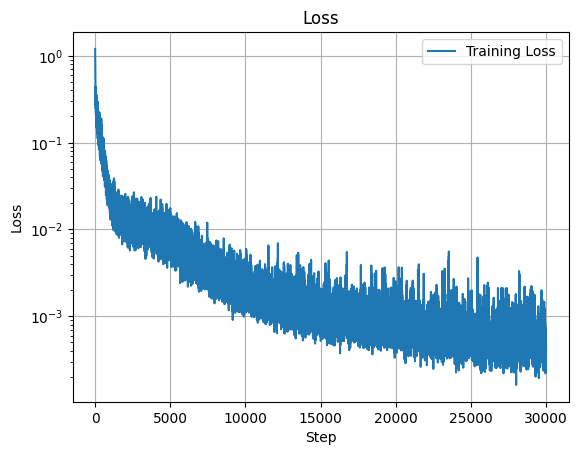

In [180]:
plt.semilogy(losses, label='Training Loss')
# plt.semilogy(val_losses, label='Validation Loss')
plt.title('Loss'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.grid(); plt.legend(); plt.show()

In [164]:
def Euler(nn, q0, q0_t, us, dt):
    qs = [q0]
    qs_t = [q0_t]
    qs_tt = []
    
    q = q0
    q_t = q0_t

    for u in us:
        x = jnp.concatenate([q, q_t, u])
        q_tt = nn(x)
        qs_tt.append(q_tt)

        # Euler integration 
        q_t = q_t + q_tt * dt
        q = q + q_t * dt

        qs.append(q)
        qs_t.append(q_t)

    return jnp.stack(qs[:-1]), jnp.stack(qs_t[:-1]), jnp.stack(qs_tt)


In [181]:
def Runge_Kutta(nn, q0, q0_t, us, dt):
    qs = [q0]
    qs_t = [q0_t]
    qs_tt = []

    q = q0
    q_t = q0_t

    for u in us:
        def f(state):
            q, q_t = state
            x = jnp.concatenate([q, q_t, u])
            q_tt = nn(x)
            return (q_t, q_tt)  

        # Compute RK4 stages
        k1_q, k1_qt = f((q, q_t))
        k2_q, k2_qt = f((q + 0.5*dt*k1_q, q_t + 0.5*dt*k1_qt))
        k3_q, k3_qt = f((q + 0.5*dt*k2_q, q_t + 0.5*dt*k2_qt))
        k4_q, k4_qt = f((q + dt*k3_q, q_t + dt*k3_qt))

        q = q + (dt/6)*(k1_q + 2*k2_q + 2*k3_q + k4_q)
        q_t = q_t + (dt/6)*(k1_qt + 2*k2_qt + 2*k3_qt + k4_qt)

        x = jnp.concatenate([q, q_t, u])
        q_tt = nn(x)  
        qs.append(q)
        qs_t.append(q_t)
        qs_tt.append(q_tt)

    return jnp.stack(qs[:-1]), jnp.stack(qs_t[:-1]), jnp.stack(qs_tt)


In [182]:
i = 5
D = 4

# Initial states should be normilized
q0_std = (y0_test[i, :D] -qs_mean) / qs_std 
q_dot0_std = (y0_test[i, D:2*D] - qs_t_mean) / qs_t_std 

q0= (y0_test[i, :D] -qs_mean) / qs_std 
q_dot0 = T**(y0_test[i, D:2*D] -qs_t_mean )/ qs_t_std

# Controls are normalized and should stay normalized as input to the NN
us_std = (us_test[i] - us_mean) / us_std

dt = ts[1] - ts[0]

q_pred_norm_euler, q_t_pred_norm_euler, q_tt_pred_norm_euler =Euler(nn, q0_std, q_dot0_std, us_std, dt)
q_pred_norm_rung, q_t_pred_norm_rung, q_tt_pred_norm_rung =Runge_Kutta(nn, q0, q_dot0, us_std, dt)

q_tt_pred_euler = (q_tt_pred_norm_euler * qs_tt_std) +qs_tt_mean
q_pred_euler = (q_pred_norm_euler * qs_std) +qs_mean

q_tt_pred_rung = (q_tt_pred_norm_rung * qs_tt_std) +qs_tt_mean
q_pred_rung = (q_pred_norm_rung * qs_std) +qs_mean

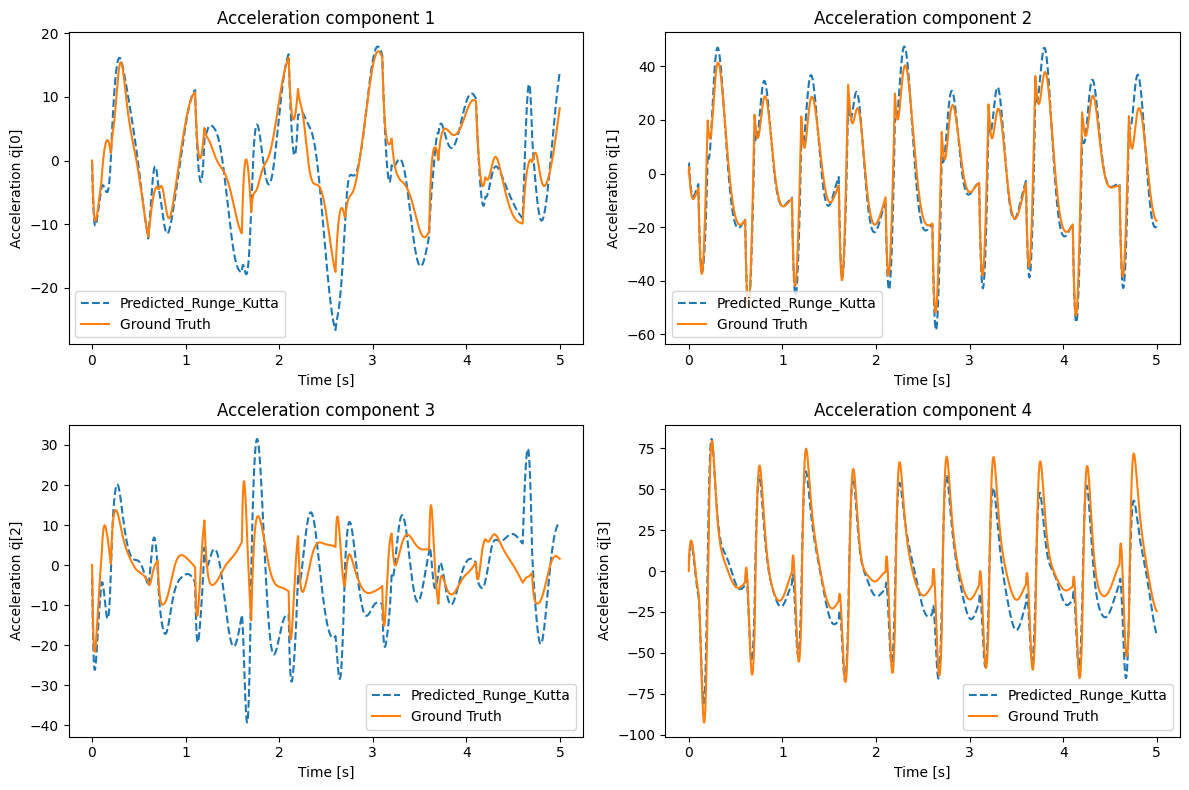

In [183]:
import matplotlib.pyplot as plt

T= q_tt_pred_rung.shape[0]


plt.figure(figsize=(12, 8))

for dim in range(4):
    plt.subplot(2, 2, dim+1)
    #plt.plot(ts[:T], q_tt_pred_euler[:, dim], label="Predicted_Euler", linestyle='dashed')
    plt.plot(ts[:T], q_tt_pred_rung[:, dim], label="Predicted_Runge_Kutta", linestyle='dashed')
    plt.plot(ts[:T], qs_tt_test[i, :T, dim], label="Ground Truth")
    plt.xlabel("Time [s]")
    plt.ylabel(f"Acceleration q̈[{dim}]")
    plt.legend()
    plt.title(f"Acceleration component {dim+1}")

plt.tight_layout()
plt.show()


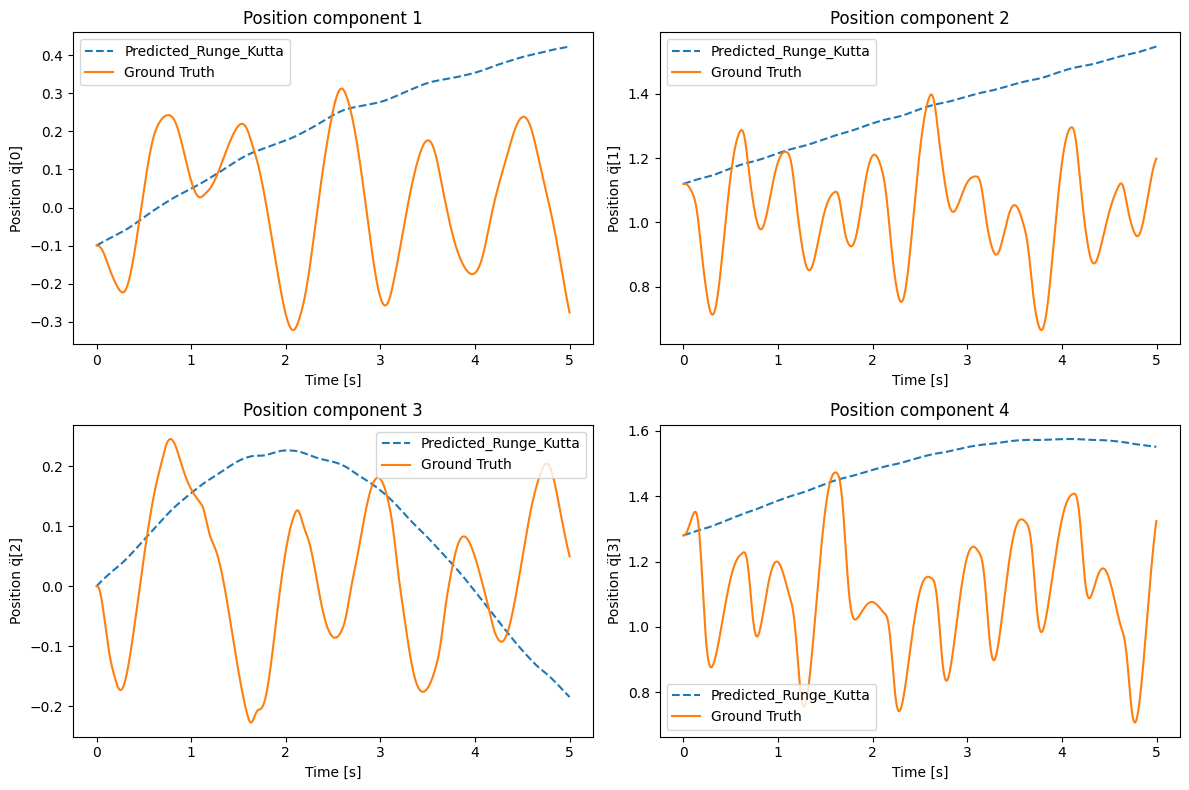

In [185]:
plt.figure(figsize=(12, 8))

T_new = int(1*T)

for dim in range(4):
    plt.subplot(2, 2, dim+1)
    #plt.plot(ts[:T], q_pred_euler[:, dim], label="Predicted_Euler", linestyle='dashed')
    plt.plot(ts[:T_new], q_pred_rung[:T_new, dim], label="Predicted_Runge_Kutta", linestyle='dashed')
    plt.plot(ts[:T_new], qs_test[i, :T_new, dim], label="Ground Truth")
    plt.xlabel("Time [s]")
    plt.ylabel(f"Position q̈[{dim}]")
    plt.legend()
    plt.title(f"Position component {dim+1}")

plt.tight_layout()
plt.show()

# Solve the problem with Neural ODE + Manual ODE solving

### inputs [q , q_t]

### control [u]

### output [q_t , q_tt]

In [186]:
class NeuralODE(eqx.Module):
    mlp: eqx.nn.MLP
    solver: diffrax.AbstractSolver
    stepsize_controller: diffrax.AbstractStepSizeController
    state_size: int
    control_size: int
    output_size: int

    def __init__(
        self, 
        state_size: int = 8,       # 4 degree + 4 velocity
        control_size: int= 4,       # 4 torque
        output_size: int = 8,      # 4 velocity + 4 acceleration 
        nn_width: int = 64,
        nn_depth: int = 2,
        *,
        key: PRNGKeyArray,
        solver: diffrax.AbstractSolver = diffrax.Tsit5(),
        #solver: diffrax.AbstractSolver = diffrax.Euler(),
        stepsize_controller: diffrax.AbstractStepSizeController = diffrax.PIDController(rtol=1e-3, atol=1e-6),
    ):
        super().__init__()
        self.state_size = state_size
        self.control_size = control_size
        self.output_size = output_size
        self.solver = solver
        self.stepsize_controller = stepsize_controller

        self.mlp = eqx.nn.MLP(
            in_size=state_size + control_size,
            out_size=output_size,
            width_size=nn_width,
            depth=nn_depth,
            activation=jnn.softplus,
            #activation= jnn.tanh,
            key=key
        )

    def __call__(self ,y: Array , u:Array) -> Array:
        """Predict dy/dt given state y and control u"""
        input = jnp.concatenate([y,u] , axis=-1)
        return self.mlp(input)  

In [187]:
# Load the data
data = jnp.load('juggle_data.npz')
ts = data['ts']       # shape: (T,)
us = data['us']       # shape: (N, T, DOF)
qs = data['qs']       # shape: (N, T, DOF)
qs_t = data['qs_t']   # shape: (N, T, DOF)
qs_tt = data['qs_tt'] # shape: (N, T, DOF)

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

T_total = ts.shape[0]
T_cut = int(0.5 * T_total)

# 2. Truncate the time series
ts = ts[:T_cut]
us = us[:, :T_cut, :]
qs = qs[:, :T_cut, :]
qs_t = qs_t[:, :T_cut, :]
qs_tt = qs_tt[:, :T_cut, :]

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

# Compute Standardization statistics on the *entire* dataset BEFORE splitting
qs_mean, qs_std = jnp.mean(qs, axis=(0,1)), jnp.std(qs, axis=(0,1))
qs_t_mean, qs_t_std = jnp.mean(qs_t, axis=(0,1)), jnp.std(qs_t, axis=(0,1))
qs_tt_mean, qs_tt_std = jnp.mean(qs_tt, axis=(0,1)), jnp.std(qs_tt, axis=(0,1))
us_mean, us_std = jnp.mean(us, axis=(0,1)), jnp.std(us, axis=(0,1))


# Number of training trajectories
n_train = 40

# Split the data along the trajectory axis (axis=0)
qs_train = qs[:n_train]
qs_t_train = qs_t[:n_train]
qs_tt_train = qs_tt[:n_train]
us_train = us[:n_train]

qs_test = qs[n_train:]
qs_t_test = qs_t[n_train:]
qs_tt_test = qs_tt[n_train:]
us_test = us[n_train:]


qs_train_std = (qs_train - qs_mean) / qs_std
qs_train_t_std = (qs_t_train - qs_t_mean) / qs_t_std
qs_train_tt_std = (qs_tt_train - qs_tt_mean) / qs_tt_std
us_train_std = (us_train - us_mean) / us_std

ts shape: (5001,)
us shape: (50, 5001, 4)
qs shape: (50, 5001, 4)
ts shape: (2500,)
us shape: (50, 2500, 4)
qs shape: (50, 2500, 4)


In [188]:
y0_test = jnp.concatenate([qs_test[:, 0, :], qs_t_test[:, 0, :]], axis=-1)  # build the intial condition based on T0 data from test data for post processing
us_test = us_test  # Already in correct shape from your dataset
print (y0_test[0])
print (y0_test.shape)
print (us_test.shape)
y_test = jnp.concatenate([qs_test, qs_t_test], axis=-1) 


N, T, DOF = qs.shape

# Reshape to (N*T, DOF) for derivative fitting
qs_flat = qs_train_std.reshape(-1, DOF)       # (N*T, 4)
qs_t_flat = qs_train_t_std.reshape(-1, DOF)   # (N*T, 4)
qs_tt_flat = qs_train_tt_std.reshape(-1, DOF) # (N*T, 4)
us_flat = us_train_std.reshape(-1, DOF)       # (N*T, 4)

x = jnp.concatenate([qs_flat, qs_t_flat, us_flat], axis=-1) # input [q , q_t , u]

y = jnp.concatenate([qs_t_flat, qs_tt_flat], axis=-1) # output [q_t, q_tt]

derivative_data_train = (x, y) 

print(derivative_data_train[0].shape)
print(derivative_data_train[1].shape)

[-0.1   1.12  0.    1.28  0.    0.    0.    0.  ]
(10, 8)
(10, 2500, 4)
(100000, 12)
(100000, 8)


In [189]:
def _dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = min(batch_size, dataset_size)
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size
@eqx.filter_value_and_grad                    
def grad_loss(model, batch_X, batch_y_t):
    y = batch_X[:, :8]   # q and q̇
    u = batch_X[:, 8:]   # control inputs
    y_t_pred = jax.vmap(model)(y, u)
    return jnp.mean((batch_y_t - y_t_pred) ** 2)

@eqx.filter_jit                                 
def make_step(batch_X, batch_y_t, model, optim, opt_state):
    loss, grads = grad_loss(model, batch_X, batch_y_t)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

def train(
    model, training_data,
    *, key,
    batch_size=64,
    lr=1e-3,
    steps=1000,
    print_every=100,
    ):

    y, y_t = training_data

    losses = []

    start_time = time.time()
    optim = optax.adabelief(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
    for step, (_y, _y_t) in zip(
        range(steps), _dataloader((y, y_t), batch_size, key=key)
    ):
        loss, model, opt_state = make_step(_y, _y_t, model, optim, opt_state)
        losses.append(loss)
        if (step % print_every) == 0 or step == steps - 1:
            print(f"Step: {step}, Loss: {loss:.3e}")
    training_time = time.time() - start_time
    print(f'Training took: {training_time:-2f}s')

    return model, losses

In [190]:
import time
key = jr.key(0)

model_key, loader_key = jr.split(key, 2)

nn = NeuralODE(state_size=8, control_size=4, output_size=8, key=model_key)


In [191]:
nn, losses = train(nn, derivative_data_train, key=loader_key, steps=30000,print_every=500)

Step: 0, Loss: 1.214e+00
Step: 500, Loss: 4.289e-02
Step: 1000, Loss: 1.557e-02
Step: 1500, Loss: 8.437e-03
Step: 2000, Loss: 7.182e-03
Step: 2500, Loss: 6.653e-03
Step: 3000, Loss: 4.394e-03
Step: 3500, Loss: 7.664e-03
Step: 4000, Loss: 5.071e-03
Step: 4500, Loss: 4.036e-03
Step: 5000, Loss: 4.781e-03
Step: 5500, Loss: 5.297e-03
Step: 6000, Loss: 2.568e-03
Step: 6500, Loss: 2.442e-03
Step: 7000, Loss: 4.931e-03
Step: 7500, Loss: 3.772e-03
Step: 8000, Loss: 2.521e-03
Step: 8500, Loss: 2.678e-03
Step: 9000, Loss: 2.526e-03
Step: 9500, Loss: 2.608e-03
Step: 10000, Loss: 2.545e-03
Step: 10500, Loss: 2.503e-03
Step: 11000, Loss: 2.214e-03
Step: 11500, Loss: 2.258e-03
Step: 12000, Loss: 2.485e-03
Step: 12500, Loss: 2.679e-03
Step: 13000, Loss: 1.969e-03
Step: 13500, Loss: 2.282e-03
Step: 14000, Loss: 2.600e-03
Step: 14500, Loss: 1.934e-03
Step: 15000, Loss: 1.158e-03
Step: 15500, Loss: 1.336e-03
Step: 16000, Loss: 1.508e-03
Step: 16500, Loss: 1.714e-03
Step: 17000, Loss: 1.077e-03
Step: 175

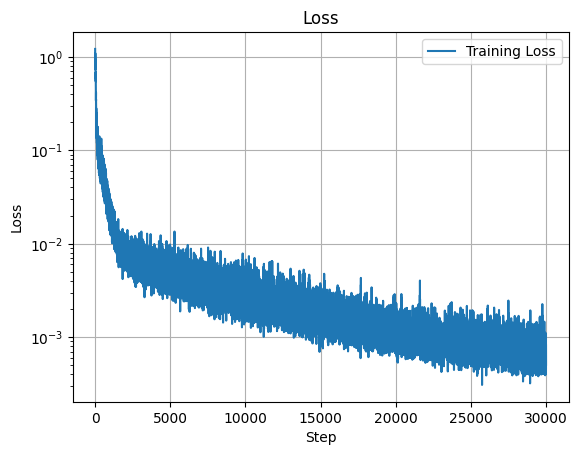

In [192]:
plt.semilogy(losses, label='Training Loss')
# plt.semilogy(val_losses, label='Validation Loss')
plt.title('Loss'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.grid(); plt.legend(); plt.show()

In [193]:
i = 5
D = 4
# Initial states should be standardized
q0_std = (y0_test[i, :D] - qs_mean) / qs_std
q0_t_std = (y0_test[i, D:2*D] - qs_t_mean) / qs_t_std
print (q0_std)
print (q0_t_std)
y0_norm = jnp.concatenate([q0_std, q0_t_std]) 


# Controls should be standardized and stay standardized as input to the NN
us_std_test = (us_test[i] - us_mean) / us_std
print (us_std_test)


[-0.6504161   0.55229616 -0.0107727   1.0295624 ]
[-0.00663505 -0.00352967 -0.00087541  0.00642013]
[[ 0.02229854  0.16624567 -0.01918294  0.16478834]
 [ 0.02229854  0.16624567 -0.01918294  0.16478834]
 [-0.01906385  0.13644044 -0.13951512  0.16694309]
 ...
 [ 1.1033853  -0.88364834 -0.998446   -0.8866448 ]
 [ 1.1245778  -0.88296616 -1.0145193  -0.8909103 ]
 [ 1.1453937  -0.8816419  -1.03025    -0.8945078 ]]


In [ ]:
def Runge_Kutta2(nn, q0, q0_t, us, dt):
    qs = [q0]
    qs_t = [q0_t]
    qs_tt = []

    q = q0
    q_t = q0_t

    for u in us:
        def f(state):
            q, q_t = state
            x = jnp.concatenate([q, q_t])
            result= nn(x,u)
            q_t = result[:4]
            q_tt = result[4:]
            return (q_t, q_tt)  

        # Compute RK4 stages
        k1_q, k1_qt = f((q, q_t))
        k2_q, k2_qt = f((q + 0.5*dt*k1_q, q_t + 0.5*dt*k1_qt))
        k3_q, k3_qt = f((q + 0.5*dt*k2_q, q_t + 0.5*dt*k2_qt))
        k4_q, k4_qt = f((q + dt*k3_q, q_t + dt*k3_qt))

        q = q + (dt/6)*(k1_q + 2*k2_q + 2*k3_q + k4_q)
        q_t = q_t + (dt/6)*(k1_qt + 2*k2_qt + 2*k3_qt + k4_qt)

        x = jnp.concatenate([q, q_t])
        result = nn(x,u)  
        q_tt = result[4:]
        qs.append(q)
        qs_t.append(q_t)
        qs_tt.append(q_tt)

    return jnp.stack(qs[:-1]), jnp.stack(qs_t[:-1]), jnp.stack(qs_tt)

In [195]:
dt = ts[1] - ts[0]
ys_pred_std , ys_t_pred_std , ys_tt_pred_std   = Runge_Kutta2(nn, q0_std,q0_t_std,us_std_test,dt)

In [196]:
# DE-Standardization of prediction to compare with true test value
q_pred = ys_pred_std * qs_std + qs_mean
q_tt_pred = ys_tt_pred_std *qs_tt_std + qs_tt_mean
print (q_pred)
print (q_tt_pred)

[[-1.0000000e-01  1.1200000e+00  0.0000000e+00  1.2800000e+00]
 [-9.9998996e-02  1.1200005e+00 -2.8235372e-06  1.2800022e+00]
 [-9.9997967e-02  1.1200011e+00 -5.6381105e-06  1.2800046e+00]
 ...
 [-1.7686754e-02  9.3578511e-01  3.8760681e-02  1.5509249e+00]
 [-1.7738162e-02  9.3564546e-01  3.8585775e-02  1.5511395e+00]
 [-1.7788894e-02  9.3550509e-01  3.8410939e-02  1.5513535e+00]]
[[  0.08044499   2.5281978    0.15392926   8.557689  ]
 [  0.08046091   2.5281844    0.15393311   8.557501  ]
 [ -1.2578048    1.344337    -3.5470488   10.321862  ]
 ...
 [ 10.173899   -22.81197      1.1679157  -19.725756  ]
 [ 10.421755   -22.737577     1.3217689  -20.017376  ]
 [ 10.666584   -22.647917     1.4763359  -20.289963  ]]


In [197]:
q_true = qs_test[i]
q_tt_true = qs_tt_test[i]
print (q_true)

[[-1.00000000e-01  1.12000000e+00  0.00000000e+00  1.28000000e+00]
 [-9.99999907e-02  1.12000978e+00  9.02963386e-10  1.28003356e+00]
 [-1.00005378e-01  1.12002429e+00 -1.46757165e-05  1.28010800e+00]
 ...
 [-2.71596532e-01  1.19617945e+00  5.25422636e-02  1.31571400e+00]
 [-2.73877509e-01  1.19759730e+00  5.12018600e-02  1.32015237e+00]
 [-2.76125636e-01  1.19894467e+00  4.98677508e-02  1.32449276e+00]]


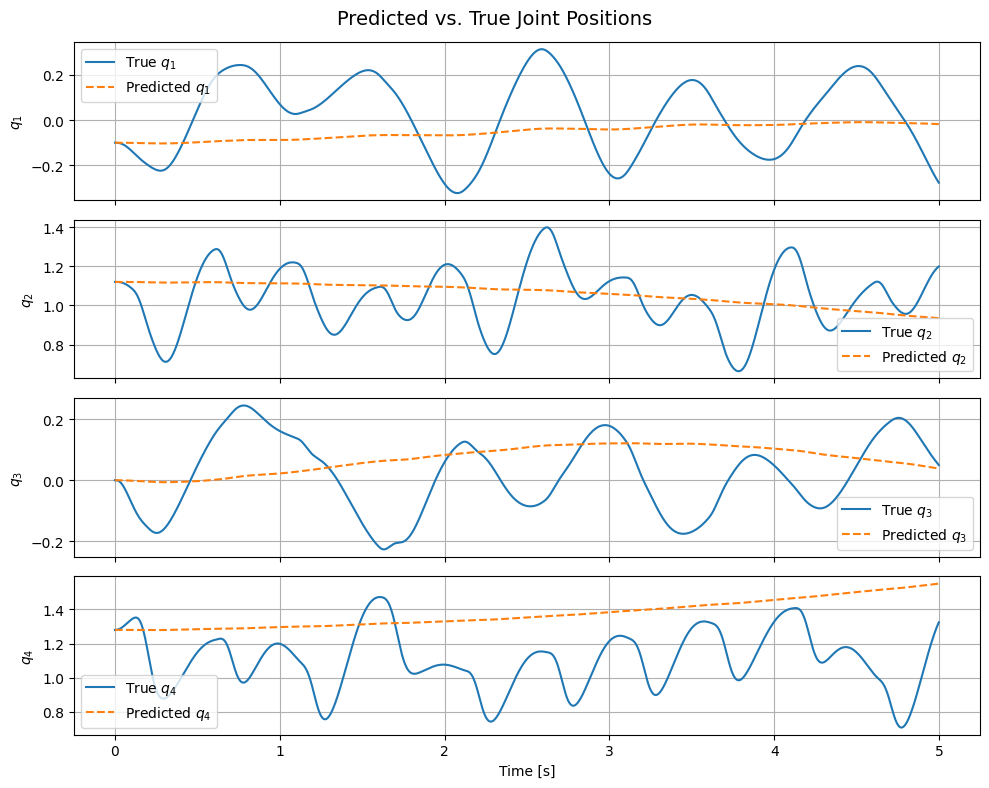

In [198]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for j in range(4):
    axs[j].plot(ts, q_true[:, j], label=f"True $q_{j+1}$")
    axs[j].plot(ts, q_pred[:, j], '--', label=f"Predicted $q_{j+1}$")
    axs[j].set_ylabel(f"$q_{j+1}$")
    axs[j].legend()
    axs[j].grid(True)

axs[-1].set_xlabel("Time [s]")
fig.suptitle("Predicted vs. True Joint Positions", fontsize=14)
plt.tight_layout()
plt.show()


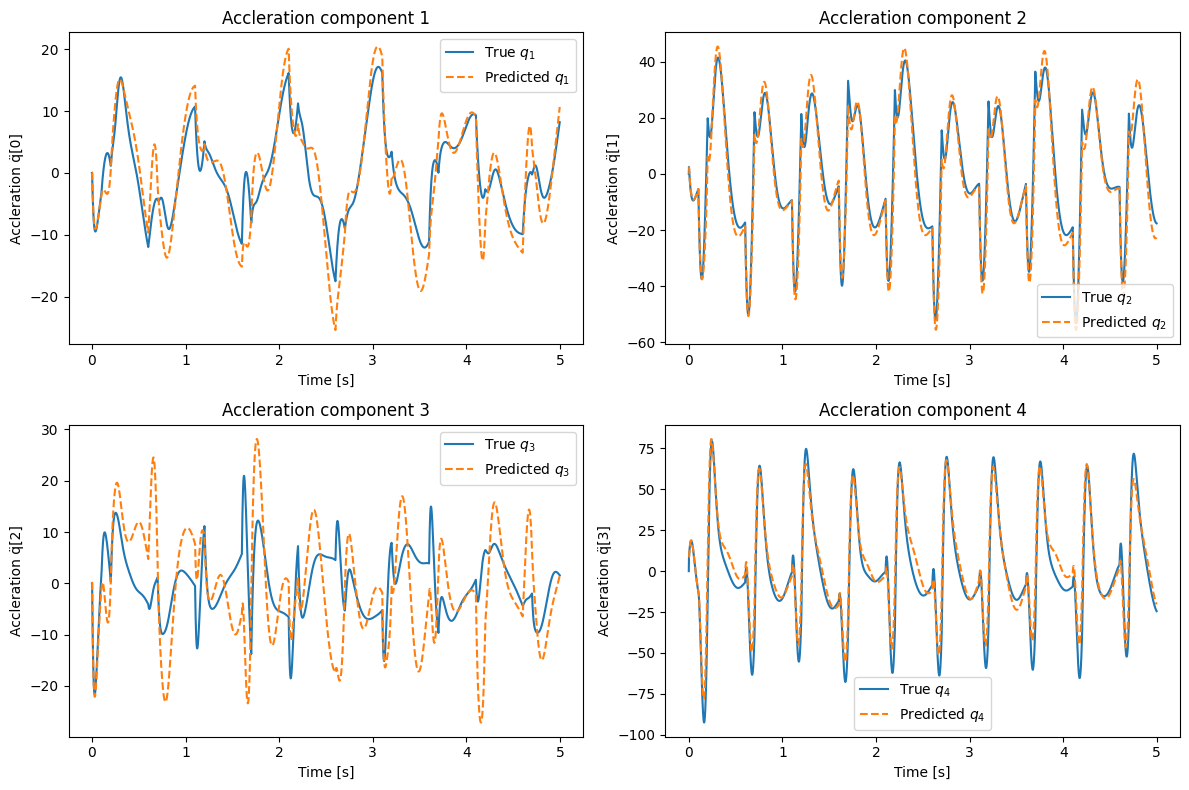

In [199]:
plt.figure(figsize=(12, 8))

for j in range(4):
    plt.subplot(2, 2, j+1)
    plt.plot(ts, q_tt_true[:, j], label=f"True $q_{j+1}$")
    plt.plot(ts, q_tt_pred[:, j], '--', label=f"Predicted $q_{j+1}$")
    plt.xlabel("Time [s]")
    plt.ylabel(f"Accleration q̈[{j}]")
    plt.legend()
    plt.title(f"Accleration component {j+1}")


plt.tight_layout()
plt.show()





# Solve the problem with Neural ODE + ODE SOLVER

### inputs [q , q_t]

### control [u]

### output [q_t , q_tt]

In [88]:
class ODESolver(eqx.Module):
    derivative_model: eqx.Module
    solver: diffrax.AbstractSolver
    stepsize_controller: diffrax.AbstractStepSizeController
    max_steps: int

    def __init__(self, 
                 derivative_model: eqx.Module, 
                 *, 
                 solver: diffrax.AbstractSolver = diffrax.Tsit5(),
                 #solver : diffrax.AbstractSolver = diffrax.Dopri8(),
                 #solver: diffrax.AbstractSolver = diffrax.Euler(),
                 stepsize_controller: diffrax.AbstractStepSizeController = diffrax.PIDController(rtol=1e-6, atol=1e-6),
                 max_steps: int = 4096):
        """Numerically solve the ODE `dy_dt = derivative_model(y, u(t))`."""
        super().__init__()
        self.derivative_model = derivative_model
        self.solver = solver
        self.stepsize_controller = stepsize_controller
        self.max_steps = max_steps

    def __call__(self, ts: Array, y0: Array, us: Array | None) -> Array:
        """Solve the ODE and return the solution without augmented dims."""
        return self._solve(ts, y0, us).ys

    def _solve(self, ts: Array, y0: Array, us: Array | None) -> diffrax.Solution:
        """Run the solver and return the full Diffrax solution."""

        # Interpolate inputs if available
        if us is not None:
            coeffs = backward_hermite_coefficients(ts, us)
            u_interp = CubicInterpolation(ts, coeffs)
        else:
            u_interp = None

        # Define ODE function
        def func(t, y, u_interp):
            if u_interp is None:
                u = None
            else:
                u = u_interp.evaluate(t)
            return self.derivative_model(y,u)
        
        # Solve ODE
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(func),
            self.solver,
            t0=ts[0], t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=u_interp,
            saveat=diffrax.SaveAt(ts=ts),
            stepsize_controller=self.stepsize_controller,
            max_steps=self.max_steps,
        )

        return solution


In [89]:
nn_ode = ODESolver(nn)
print (ts.shape)
print (y0_norm.shape)
print (us_std_test.shape)

ys_pred_std= nn_ode(ts,y0_norm,us_std_test)
print (ys_pred_std.shape)


(2500,)
(8,)
(2500, 4)
(2500, 8)


In [90]:
q_pred_std = ys_pred_std[:,:D]
print (q_pred_std.shape)

q_pred = (q_pred_std * qs_std) + qs_mean

print (q_pred)

(2500, 4)
[[-1.0000000e-01  1.1200000e+00  0.0000000e+00  1.2800000e+00]
 [-1.0000422e-01  1.1199970e+00  6.1769970e-07  1.2800004e+00]
 [-1.0000857e-01  1.1199942e+00  1.4092075e-06  1.2800007e+00]
 ...
 [-1.8388487e-02  9.1597360e-01  4.3122865e-02  1.5567776e+00]
 [-1.8443264e-02  9.1581947e-01  4.2945530e-02  1.5570028e+00]
 [-1.8497569e-02  9.1566473e-01  4.2768225e-02  1.5572275e+00]]


In [91]:
print (q_true)

[[-1.00000000e-01  1.12000000e+00  0.00000000e+00  1.28000000e+00]
 [-9.99999907e-02  1.12000978e+00  9.02963386e-10  1.28003356e+00]
 [-1.00005378e-01  1.12002429e+00 -1.46757165e-05  1.28010800e+00]
 ...
 [-2.71596532e-01  1.19617945e+00  5.25422636e-02  1.31571400e+00]
 [-2.73877509e-01  1.19759730e+00  5.12018600e-02  1.32015237e+00]
 [-2.76125636e-01  1.19894467e+00  4.98677508e-02  1.32449276e+00]]


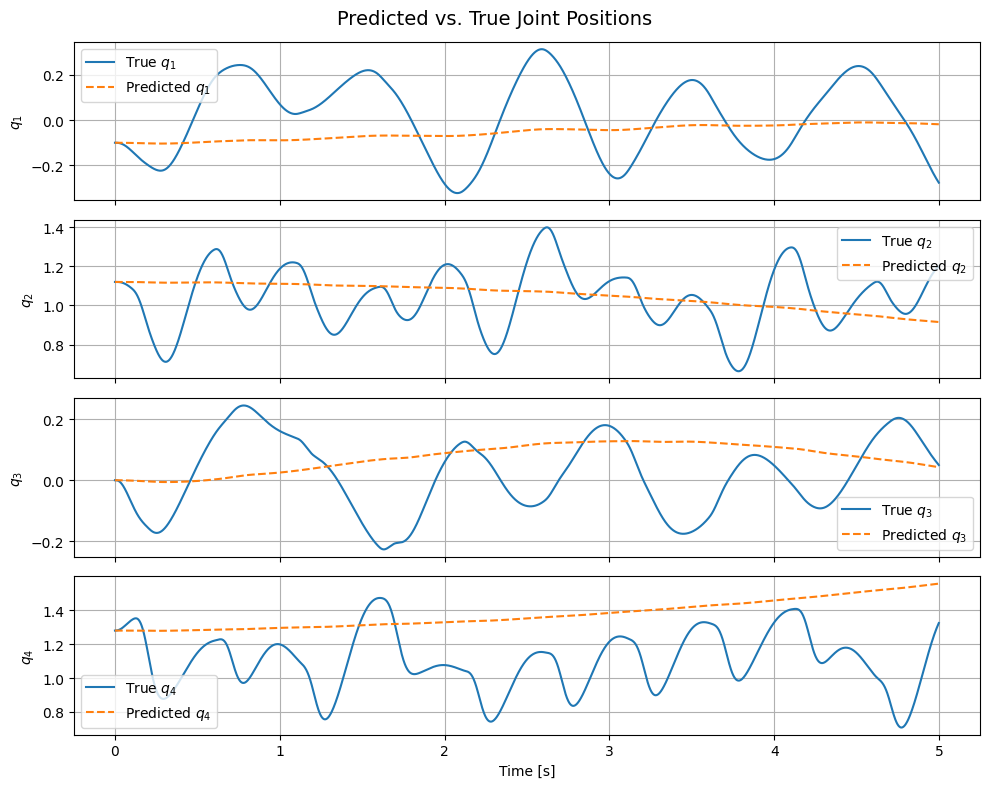

In [92]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for j in range(4):
    axs[j].plot(ts, q_true[:, j], label=f"True $q_{j+1}$")
    axs[j].plot(ts, q_pred[:, j], '--', label=f"Predicted $q_{j+1}$")
    axs[j].set_ylabel(f"$q_{j+1}$")
    axs[j].legend()
    axs[j].grid(True)

axs[-1].set_xlabel("Time [s]")
fig.suptitle("Predicted vs. True Joint Positions", fontsize=14)
plt.tight_layout()
plt.show()